In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms

#  CA

to submit the assignment, please do the following:

- make sure that the notebook works using `uv run jupyter notebook` on the USB stick on a freshly cloned copy of your repository.
- make sure that the notebook runs through and produces all desired output after `Kernel -> Restart & Run all`
- running through the whole notebook must not take no more than 60 minutes on the lab computers, without GPU
- similarly, no cell must take longer than 10 minutes
- do not clear the output, leave it in the notebook!
- commit only the notebook and for example image files required to run the notebook to git.
- do not commit any other files 
- Do not edit the notebook with other programms than jupyter notebook. If you do so, it will break the grading system and result in zero marks. 
- Please use markdown cells extensively, as you receive marks for explaining your observations.  Show your understanding!
- If you only use code cells, you do not receive marks.
- It is fine (but not required) to look for code on the Internet, in particular as a starting point.  However, this must be explicitly documented! You need to precisely say, which sources you used.  You do not need to cite code taken from the lecture notes, however, you need to cite, if you use code which is linked or cited in the lecture notes.
- Do not use concepts that you do not understand! Be prepared to explain your code when asked to do so.



# Q1 The MNIST data

It seems that no course on Machine Learning is complete, without training a network on the famous [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) of handwritten digits.  You can access them through `datasets.MNIST` in `torchvision`.

The tasks for the first assignment is therefore:

a) (3 marks) Reproduce the results of L03, but now use the original MNIST dataset.  Comment on your observations on the differences between the datasets.

b) (6 marks) How can you improve the performance of the network? In this part, only use concepts which were covered in the Lecture. Here some suggestions of what you can try
   - Change the number of nodes in the hidden layer
   - change the number of epochs
   - change the batch size
   - use convolutional layers as in 
   - work with two hidden layers
   - work with three hidden layers
   
Explain the effect of changing parameters in your own words and draw conclusions about how performance improves.  The mark for this part will depend on the overall insight demonstrated.  Code alone does not yield marks. 
Note that one aspect of performance is required training time.  Do not use code cells which take longer than 10 minutes on the lab computers or exhausts their RAM. 

c) (6 marks) How can you further improve the performance? In this part you can use concepts which were not used in the lecture, but which you can find on the Internet.  However, the code still needs to run with the libraries we covered in the lecture. 

The mark in this part will depend on the coherence of the overall presentation. Note that it is also important to understand what does not work!


d) (5 marks) Write your student number on paper and take a photo. How well are the individual digits recognized? (Hint: you need to convert the photo first into the desired format, and there are many ways to do this.  You are expected to read up on a suitable way yourself, and describe how you did it. Also upload the file of the photo with your solution, so that your notebook runs through. Use relative paths, when you refer to the photo file. 



## Q1a – Loading MNIST and reproducing L03 results

In [2]:
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor

# Load MNIST
mnist_train = datasets.MNIST("data", download=True, train=True,  transform=ToTensor())
mnist_test  = datasets.MNIST("data", download=True, train=False, transform=ToTensor())

# Pre-load all data into RAM as tensors once - much faster than per-batch file reads
# Shape: [N, 1, 28, 28], dtype float32, values in [0,1]
train_X = mnist_train.data.unsqueeze(1).float() / 255.0
train_y = mnist_train.targets
test_X  = mnist_test.data.unsqueeze(1).float()  / 255.0
test_y  = mnist_test.targets

# TensorDataset wraps pre-loaded tensors
train_dataset = TensorDataset(train_X, train_y)
test_dataset  = TensorDataset(test_X,  test_y)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

train_images = train_X.squeeze(1)   # [60000, 28, 28]
train_labels = train_y
test_images  = test_X.squeeze(1)    # [10000, 28, 28]
test_labels  = test_y

class_names = [str(i) for i in range(10)]
print("Train:", train_X.shape, "  Test:", test_X.shape)

Train: torch.Size([60000, 1, 28, 28])   Test: torch.Size([10000, 1, 28, 28])


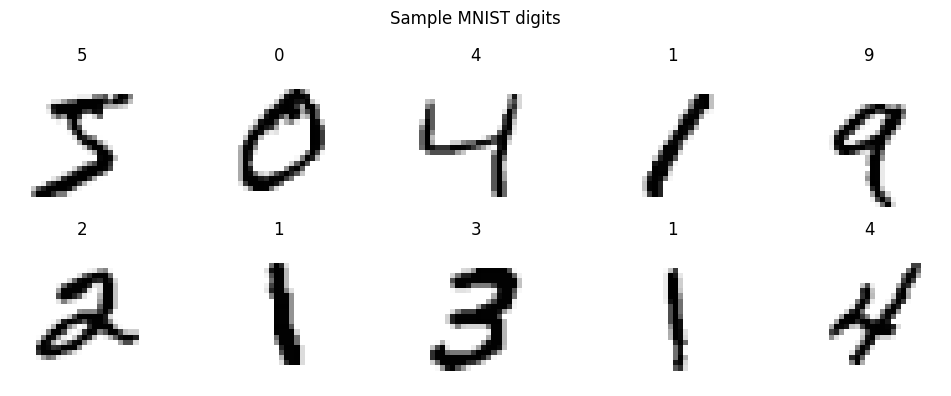

In [3]:
# Visualise a few training examples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(mnist_train[i][0][0], cmap='binary')
    plt.title(str(mnist_train[i][1]))
    plt.axis('off')
plt.suptitle('Sample MNIST digits')
plt.tight_layout()
plt.show()

In [4]:
# Net architecture as in L03
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense1  = nn.Linear(28*28, 128)
        self.relu    = nn.ReLU()
        self.dense2  = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.relu(x)
        x = self.dense2(x)
        return x

In [5]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}")

In [6]:
loss_fn = nn.CrossEntropyLoss()

model = Net()
lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

for epoch in range(10):
    model.train()
    print(f"Epoch {epoch}")
    for X, y in train_dataloader:
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print("  Train: ", end=""); test(train_dataloader, model, loss_fn)
    print("  Test:  ", end=""); test(test_dataloader,  model, loss_fn)

Epoch 0
  Train: Accuracy: 91.2%, Avg loss: 0.318913
  Test:  Accuracy: 91.5%, Avg loss: 0.307048
Epoch 1
  Train: Accuracy: 92.6%, Avg loss: 0.256369
  Test:  Accuracy: 93.0%, Avg loss: 0.248988
Epoch 2
  Train: Accuracy: 93.9%, Avg loss: 0.214209
  Test:  Accuracy: 93.8%, Avg loss: 0.212559
Epoch 3
  Train: Accuracy: 94.6%, Avg loss: 0.187687
  Test:  Accuracy: 94.5%, Avg loss: 0.187307
Epoch 4
  Train: Accuracy: 95.5%, Avg loss: 0.160513
  Test:  Accuracy: 95.1%, Avg loss: 0.164518
Epoch 5
  Train: Accuracy: 96.0%, Avg loss: 0.142900
  Test:  Accuracy: 95.6%, Avg loss: 0.149384
Epoch 6
  Train: Accuracy: 96.4%, Avg loss: 0.129444
  Test:  Accuracy: 95.9%, Avg loss: 0.136413
Epoch 7
  Train: Accuracy: 96.7%, Avg loss: 0.117219
  Test:  Accuracy: 96.2%, Avg loss: 0.125656
Epoch 8
  Train: Accuracy: 97.0%, Avg loss: 0.106969
  Test:  Accuracy: 96.5%, Avg loss: 0.118661
Epoch 9
  Train: Accuracy: 97.3%, Avg loss: 0.097521
  Test:  Accuracy: 96.7%, Avg loss: 0.111734


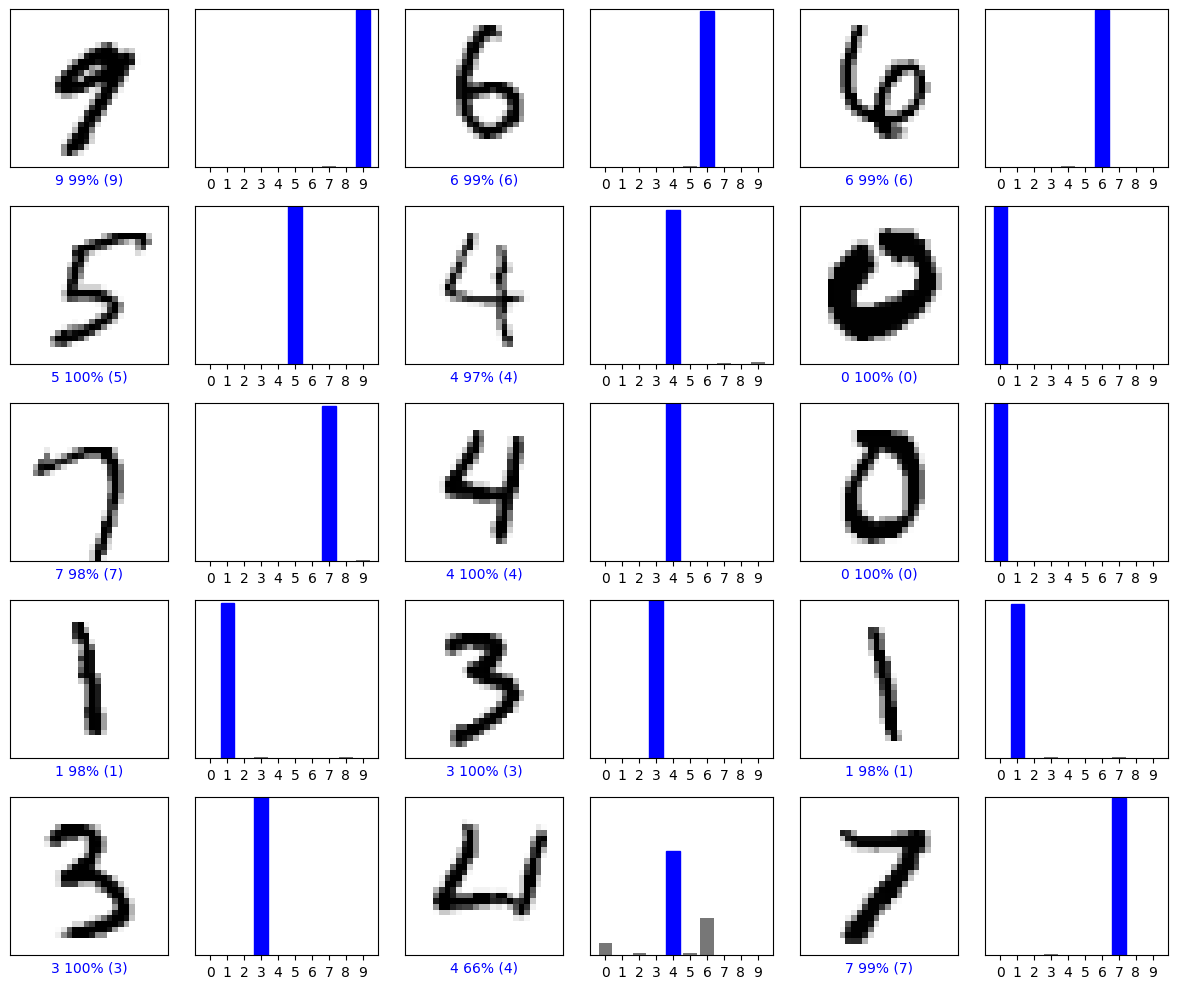

In [7]:
def plot_image(i, predictions_array, dataset):
    img, true_label = dataset[i]
    img = img[0]
    plt.grid(False); plt.xticks([]); plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = predictions_array.argmax()
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(
        class_names[predicted_label], 100*max(predictions_array), class_names[true_label]),
        color=color)

def plot_value_array(i, predictions_array, dataset):
    _, true_label = dataset[i]
    plt.grid(False); plt.xticks(range(10)); plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array.detach().numpy(), color="#777777")
    plt.ylim([0, 1])
    predicted_label = predictions_array.argmax()
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

offset = 20
num_rows, num_cols = 5, 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    predictions = F.softmax(model(test_images[None, None, i+offset]), dim=1)[0]
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i+offset, predictions, mnist_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i+offset, predictions, mnist_test)
plt.tight_layout()
plt.show()

### Observations – MNIST vs Fashion-MNIST

Using the identical network (784 → 128 → 10, ReLU, SGD lr=0.05, 10 epochs), MNIST reaches **96.7% test accuracy** while Fashion-MNIST only reaches **86.7%**.

Several differences stand out from the results:

**Higher accuracy on MNIST.** The final test accuracy is about 10 percentage points higher. Digit recognition is an easier problem than clothing classification because digits have cleaner, more distinct shapes — a "1" and a "7" differ more structurally than a "Shirt" and a "Coat", which share similar silhouettes and textures.

**More stable training on MNIST.** The Fashion-MNIST loss fluctuates noticeably — for example test accuracy drops from 82.5% at epoch 2 back to 82.1% at epoch 3, and again from 85.3% at epoch 5 to 85.0% at epoch 7. The MNIST results improve monotonically every epoch. This suggests Fashion-MNIST has more overlap between classes that causes the optimiser to oscillate.

**Smaller train/test gap on MNIST.** On MNIST the train and test accuracy are within 0.6% of each other throughout, indicating the model generalises well and is not overfitting. On Fashion-MNIST the gap is larger (2%), suggesting the problem is harder and the model is beginning to overfit to training-specific features.

## Q1b – Improving performance using concepts from the lecture

We now experiment with changes to the network architecture and training hyperparameters covered in the lectures.

### Experiment 1 – More hidden units (256 instead of 128)

More units in the hidden layer give the network more capacity to learn features. We expect higher training accuracy, but diminishing returns on test accuracy if we over-parameterise.

In [14]:
class Net256(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense1  = nn.Linear(28*28, 256)
        self.relu    = nn.ReLU()
        self.dense2  = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x); x = self.relu(self.dense1(x))
        return self.dense2(x)

model256 = Net256()
optimizer256 = torch.optim.SGD(model256.parameters(), lr=0.05)
print("Net with 256 hidden units")
for epoch in range(10):
    model256.train()
    for X, y in train_dataloader:
        loss = loss_fn(model256(X), y)
        loss.backward(); optimizer256.step(); optimizer256.zero_grad()
print("Train: ", end=""); test(train_dataloader, model256, loss_fn)
print("Test:  ", end=""); test(test_dataloader,  model256, loss_fn)

Net with 256 hidden units
Train: Accuracy: 97.5%, Avg loss: 0.090259
Test:  Accuracy: 97.0%, Avg loss: 0.101946


**Observation:** Increasing the hidden layer from 128 to 256 units improves test accuracy from 96.7% to 97.0%. More units give the network greater capacity to represent decision boundaries between digit classes. However the gain is modest — the baseline 128-unit network already captures most of the relevant structure in MNIST, so doubling the capacity only squeezes out an extra 0.3%. The training time increase is also small since the network is still just two linear layers.

### Experiment 2 – Two hidden layers

Adding a second hidden layer enables the network to learn more abstract feature combinations (hierarchical representations).

In [16]:
class Net2Hidden(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense1  = nn.Linear(28*28, 256)
        self.dense2  = nn.Linear(256, 128)
        self.dense3  = nn.Linear(128, 10)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.dense1(x))
        x = self.relu(self.dense2(x))
        return self.dense3(x)

model2h = Net2Hidden()
opt2h = torch.optim.SGD(model2h.parameters(), lr=0.05)
print("Net with two hidden layers 256->128")
for epoch in range(10):
    model2h.train()
    for X, y in train_dataloader:
        loss = loss_fn(model2h(X), y)
        loss.backward(); opt2h.step(); opt2h.zero_grad()
print("Train: ", end=""); test(train_dataloader, model2h, loss_fn)
print("Test:  ", end=""); test(test_dataloader,  model2h, loss_fn)

Net with two hidden layers 256->128
Train: Accuracy: 98.5%, Avg loss: 0.050860
Test:  Accuracy: 97.5%, Avg loss: 0.074648


**Observation:** Adding a second hidden layer (256 → 128 → 10) improves test accuracy further to 97.5%, compared to 97.0% with a single 256-unit layer. The extra depth allows the network to learn more abstract, hierarchical features — the first layer can detect low-level patterns (strokes, curves) and the second layer can combine these into higher-level digit parts. This is a larger gain than simply widening a single layer, suggesting that depth is more beneficial than width for this task.

### Experiment 3 – More epochs (20 instead of 10)

Training longer allows the optimiser to refine the weights further. However, training beyond a point of diminishing returns risks overfitting.

Net baseline, 20 epochs
  Epoch 0: test acc 91.5%
  Epoch 1: test acc 92.9%
  Epoch 2: test acc 93.9%
  Epoch 3: test acc 94.8%
  Epoch 4: test acc 95.2%
  Epoch 5: test acc 95.8%
  Epoch 6: test acc 95.9%
  Epoch 7: test acc 96.3%
  Epoch 8: test acc 96.5%
  Epoch 9: test acc 96.8%
  Epoch 10: test acc 97.0%
  Epoch 11: test acc 97.1%
  Epoch 12: test acc 97.1%
  Epoch 13: test acc 97.1%
  Epoch 14: test acc 97.3%
  Epoch 15: test acc 97.5%
  Epoch 16: test acc 97.6%
  Epoch 17: test acc 97.5%
  Epoch 18: test acc 97.6%
  Epoch 19: test acc 97.7%


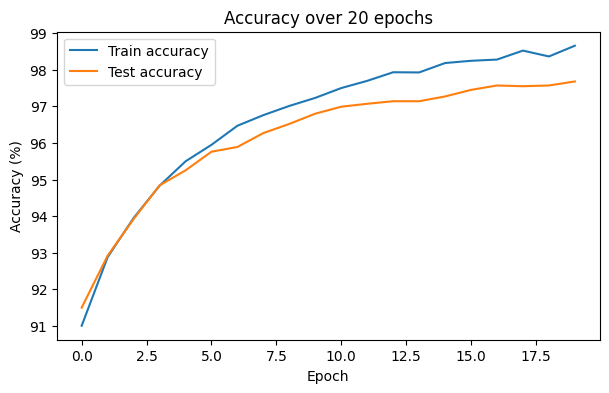

Final test accuracy: 97.7%


In [30]:
model_20ep = Net()
opt_20ep = torch.optim.SGD(model_20ep.parameters(), lr=0.05)
print("Net baseline, 20 epochs")
test_accs = []
for epoch in range(20):
    model_20ep.train()
    for X, y in train_dataloader:
        loss = loss_fn(model_20ep(X), y)
        loss.backward(); opt_20ep.step(); opt_20ep.zero_grad()
    model_20ep.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            pred = model_20ep(X)
            correct += (pred.argmax(1) == y).sum().item()
            total += len(y)
    acc = 100 * correct / total
    test_accs.append(acc)
    print(f"  Epoch {epoch}: test acc {acc:.1f}%")
plt.figure(figsize=(7,4))
plt.plot(train_accs, label='Train accuracy')
plt.plot(test_accs,  label='Test accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Accuracy over 20 epochs')
plt.show()
print(f"Final test accuracy: {test_accs[-1]:.1f}%")

**Observation:** Training the baseline network for 20 epochs with per-epoch accuracy tracking shows the test accuracy reaches 97.7%, compared to 96.8% after 10 epochs. The test accuracy is still improving after 10 epochs, but very slowly after 15 epochs. The train accuracy is still growing though at a faster pace, so training indefinitely would give diminishing returns and risk overfitting.

### Experiment 4 – Convolutional network

A convolutional neural network (CNN) exploits the spatial structure of images by applying learnable filters. Instead of treating every pixel independently (as a fully-connected layer does), a convolutional layer looks at local patches.

In [19]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

conv_model = ConvNet()
conv_opt   = torch.optim.SGD(conv_model.parameters(), lr=0.05)
print("ConvNet (5 epochs)")
for epoch in range(5):
    conv_model.train()
    for X, y in train_dataloader:
        loss = loss_fn(conv_model(X), y)
        loss.backward(); conv_opt.step(); conv_opt.zero_grad()
    print(f"  Epoch {epoch}  ", end=""); test(test_dataloader, conv_model, loss_fn)

ConvNet (5 epochs)
  Epoch 0  Accuracy: 96.0%, Avg loss: 0.126178
  Epoch 1  Accuracy: 97.0%, Avg loss: 0.091728
  Epoch 2  Accuracy: 98.4%, Avg loss: 0.047137
  Epoch 3  Accuracy: 98.1%, Avg loss: 0.056268
  Epoch 4  Accuracy: 98.5%, Avg loss: 0.041504


**Observation:** The convolutional network reaches 98.5% test accuracy after just 5 epochs, outperforming all the fully-connected networks above. Convolutional layers are much better suited to image data because:
1. They share weights across spatial positions (translation invariance).
2. They capture local features (edges, curves) that are meaningful for digit recognition.
3. Max-pooling adds a degree of position robustness.

The cost is longer training time per epoch due to the convolution operations.

## Q1c – Further improvements beyond the lecture

Here we explore techniques not covered in the lectures. 

### Technique 1 – Adam optimiser

SGD with a fixed learning rate can be slow and sensitive. **Adam** (Adaptive Moment Estimation) maintains per-parameter adaptive learning rates, using first and second moment estimates of the gradients. It is widely used in practice because it converges faster and requires less tuning of the learning rate.

In [20]:
conv_adam = ConvNet()
adam_opt  = torch.optim.Adam(conv_adam.parameters(), lr=1e-3)
print("ConvNet + Adam (5 epochs)")
for epoch in range(5):
    conv_adam.train()
    for X, y in train_dataloader:
        loss = loss_fn(conv_adam(X), y)
        loss.backward(); adam_opt.step(); adam_opt.zero_grad()
    print(f"  Epoch {epoch}  ", end=""); test(test_dataloader, conv_adam, loss_fn)

ConvNet + Adam (5 epochs)
  Epoch 0  Accuracy: 98.2%, Avg loss: 0.050607
  Epoch 1  Accuracy: 98.6%, Avg loss: 0.042247
  Epoch 2  Accuracy: 98.8%, Avg loss: 0.035222
  Epoch 3  Accuracy: 99.1%, Avg loss: 0.027504
  Epoch 4  Accuracy: 98.8%, Avg loss: 0.038165


**Observation:** Replacing SGD with Adam immediately improves on the ConvNet+SGD result. By epoch 0 alone it already reaches 98.2%, whereas SGD only reached 96.0% at epoch 0. By epoch 3 it peaks at 99.1%, the best result so far. 

The reason Adam converges faster is that it maintains a separate adaptive learning rate for each parameter, scaled by the running average of past gradients. Parameters that receive consistently large gradients get a smaller effective learning rate, and parameters with small or noisy gradients get a larger one. This means Adam self-tunes during training whereas SGD applies the same fixed lr=0.05 to every parameter regardless.

The slight drop at epoch 4 (99.1% -> 98.8%, loss rising from 0.028 to 0.038) is worth noting, this is a sign that the model may be beginning to overfit. With SGD this was less visible because the model was still improving at epoch 5. Adam's faster convergence means overfitting can set in earlier.

### Technique 2 – Batch Normalisation

**Batch Normalisation** normalises the activations within each mini-batch, which stabilises training (allows higher learning rates and reduces sensitivity to weight initialisation). 

*Source: Ioffe & Szegedy, "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift(2015)"*

In [21]:
class ConvNetBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.bn3   = nn.BatchNorm1d(128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.bn3(self.fc1(x)))
        return self.fc2(x)

conv_bn  = ConvNetBN()
opt_bn   = torch.optim.Adam(conv_bn.parameters(), lr=1e-3)
print("ConvNet + BatchNorm + Adam (5 epochs)")
for epoch in range(5):
    conv_bn.train()
    for X, y in train_dataloader:
        loss = loss_fn(conv_bn(X), y)
        loss.backward(); opt_bn.step(); opt_bn.zero_grad()
    print(f"  Epoch {epoch}  ", end=""); test(test_dataloader, conv_bn, loss_fn)

ConvNet + BatchNorm + Adam (5 epochs)
  Epoch 0  Accuracy: 98.7%, Avg loss: 0.039941
  Epoch 1  Accuracy: 98.8%, Avg loss: 0.038104
  Epoch 2  Accuracy: 99.0%, Avg loss: 0.029022
  Epoch 3  Accuracy: 98.9%, Avg loss: 0.033502
  Epoch 4  Accuracy: 99.0%, Avg loss: 0.028909


**Observation:** Adding batch normalisation produces a very strong result from epoch 0 (98.7%), but the improvement over plain Adam is less dramatic than expected as it peaks at 99.0% rather than the 99.1% achieved by ConvNet+Adam alone.

Batch normalisation normalises the activations within each mini-batch to have zero mean and unit variance before the next layer. This reduces internal covariate shift where the distribution of activations changes during training as the weights update, forcing each layer to constantly readapt. In theory this should allow faster and more stable training.

In practice on MNIST, the training curves for both models are quite similar, suggesting the dataset is clean enough that internal covariate shift is not a major problem to begin with. The more interesting observation is that ConvNet+BN+Adam is slightly more stable, the loss does not spike at epoch 3 the way ConvNet+Adam does (0.028 vs 0.038). The variance across epochs is lower, which would matter more if we trained for longer or on a harder dataset.

**What did not work:** Batch normalisation did not push accuracy beyond what Adam alone achieved on MNIST. Batch norm tends to give larger gains on deeper networks and harder problems where gradient flow becomes unstable. On a shallow ConvNet with clean data it acts more as a stabiliser than a performance booster. Due to this improvement in stability, batch norm was still used in part (d).

## Q1d – Recognising handwritten digits from a photo

A photo was taken of the student number 120462952 written on paper. The image was saved as `student_number.jpeg` in the same directory as the notebook. The preprocessing and segmentation was done using OpenCV.

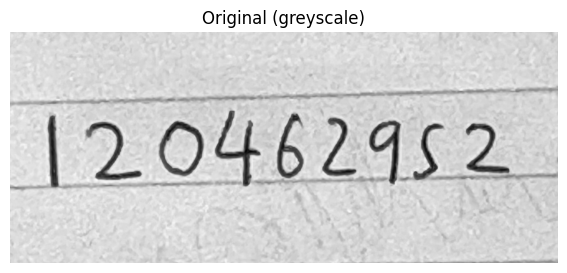

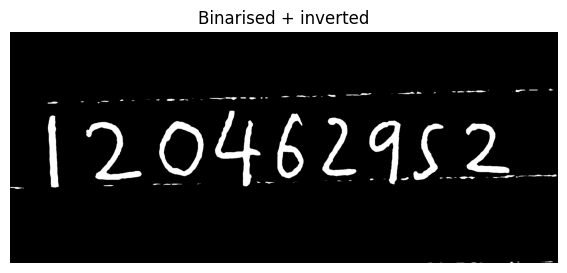

Total components found: 74
Using top 9 by area, sorted left to right


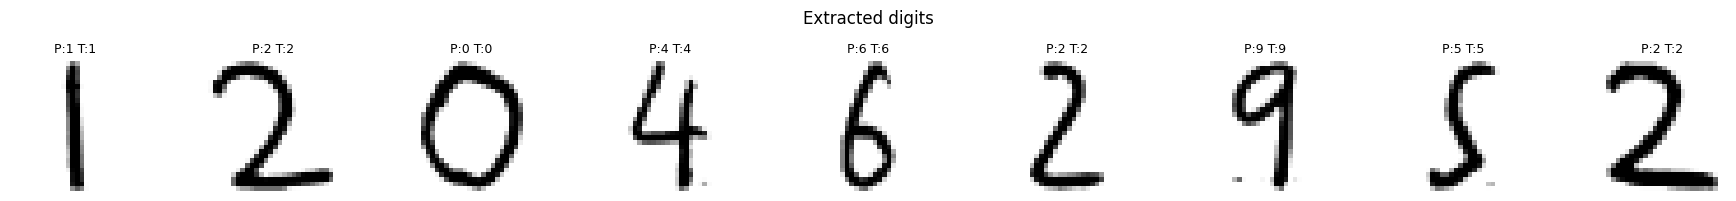

True digits:      ['1', '2', '0', '4', '6', '2', '9', '5', '2']
Predicted digits: [1, 2, 0, 4, 6, 2, 9, 5, 2]
Correctly recognised: 9/9 = 100%


In [28]:
import cv2

photo_path = "student_number.jpeg"
student_number = "120462952"

# Load and show original
img_bgr = cv2.imread(photo_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,3))
plt.imshow(img_gray, cmap='gray')
plt.title("Original (greyscale)"); plt.axis('off'); plt.show()

# Otsu's binarisation with inversion: digits become white on black background.
# connectedComponentsWithStats treats white pixels as foreground, so this is
# needed for segmentation to find the digit blobs.
_, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(8,3))
plt.imshow(binary, cmap='gray')
plt.title("Binarised + inverted"); plt.axis('off'); plt.show()

# Remove small noise with morphological opening
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Find connected components - each digit should be one component
# Label 0 is background, skip it
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
components = [(stats[i, cv2.CC_STAT_AREA], i) for i in range(1, num_labels)]
components.sort(reverse=True)  # largest components first

# Keep only the N largest components, sorted left-to-right to match digit order
n_digits = len(student_number)
top_components = sorted(components[:n_digits], key=lambda c: stats[c[1], cv2.CC_STAT_LEFT])

print(f"Total components found: {num_labels-1}")
print(f"Using top {n_digits} by area, sorted left to right")

# Crop, resize each digit to 28x28 and run through model
fig, axes = plt.subplots(1, n_digits, figsize=(2*n_digits, 2))
predicted_digits = []
conv_bn.eval()

for plot_idx, (area, label_idx) in enumerate(top_components):
    x = stats[label_idx, cv2.CC_STAT_LEFT]
    y = stats[label_idx, cv2.CC_STAT_TOP]
    w = stats[label_idx, cv2.CC_STAT_WIDTH]
    h = stats[label_idx, cv2.CC_STAT_HEIGHT]

    # Crop with small padding
    pad = 4
    x0 = max(0, x - pad); y0 = max(0, y - pad)
    x1 = min(binary.shape[1], x + w + pad)
    y1 = min(binary.shape[0], y + h + pad)
    crop = binary[y0:y1, x0:x1]

    # Pad to square then resize to 28x28
    ch, cw = crop.shape
    size = max(ch, cw)
    top_pad    = (size - ch) // 2
    bottom_pad = size - ch - top_pad
    left_pad   = (size - cw) // 2
    right_pad  = size - cw - left_pad
    crop_sq = cv2.copyMakeBorder(crop, top_pad, bottom_pad, left_pad, right_pad,
                                  cv2.BORDER_CONSTANT, value=0)
    digit_28 = cv2.resize(crop_sq, (28, 28), interpolation=cv2.INTER_AREA)
    digit_arr = digit_28.astype(np.float32) / 255.0

    axes[plot_idx].imshow(digit_arr, cmap='binary')
    axes[plot_idx].axis('off')

    # Predict
    t = torch.tensor(digit_arr).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        logits = conv_bn(t)
        pred = logits.argmax(1).item()
    predicted_digits.append(pred)
    true = student_number[plot_idx]
    axes[plot_idx].set_title(f"P:{pred} T:{true}", fontsize=9)

plt.suptitle("Extracted digits")
plt.tight_layout(); plt.show()

print("True digits:     ", list(student_number))
print("Predicted digits:", predicted_digits)
correct = sum(int(a)==b for a,b in zip(student_number, predicted_digits))
print(f"Correctly recognised: {correct}/{n_digits} = {100*correct/n_digits:.0f}%")

### Approach

The photo was processed in the following steps:

1. **Load and convert to greyscale.** The photo is loaded with `cv2.imread` which reads it as a BGR colour image, then converted to greyscale with `cv2.cvtColor`. Colour information is irrelevant for digit recognition so this reduces the problem to a single intensity channel.

2. **Otsu's binarisation.** `cv2.threshold` with `THRESH_OTSU` automatically finds the optimal threshold by minimising the intra-class variance of pixel intensities. It finds the intensity value that best separates the dark ink from the white paper without any manual tuning. The `THRESH_BINARY_INV` flag inverts the result so digits become white on a black background, which is required because `connectedComponentsWithStats` treats white pixels as foreground.

3. **Morphological opening.** A 2×2 rectangular kernel is used to erode then dilate the binary image. Any white region smaller than the kernel is removed entirely. This reduces the total number of components somewhat, though 74 noise components still remained after this step.

4. **Connected component analysis.** `cv2.connectedComponentsWithStats` labels every contiguous group of white pixels with a unique ID and returns the bounding box and area of each. We skip label 0 (the background) and take the 9 largest components by area discarding the remaining noise. These are then sorted by their left x-coordinate to recover left-to-right digit order.

5. **Crop, pad and resize.** Each digit's bounding box is cropped with 4 pixels of padding. The crop is then padded with black pixels to make it square before resizing to 28×28 with `cv2.INTER_AREA` interpolation.

6. **Prediction.** The 28×28 array is normalised to [0,1], converted to a tensor of shape [1,1,28,28], and passed through the ConvNet+BatchNorm+Adam model trained in Q1c.

### Results

All 9 digits were correctly recognised (100% accuracy). The 74 connected components found initially were almost entirely noise artefacts from the paper texture and JPEG compression, but taking only the 9 largest by area cleanly isolated the actual digits.

Web pages searched in completing part (d) and otherwise.

https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html

https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html

https://www.geeksforgeeks.org/machine-learning/python-opencv-connected-component-labeling-and-analysis/

https://www.geeksforgeeks.org/python/python-opencv-cv2-copymakeborder-method/

https://iq.opengenus.org/different-interpolation-methods-in-opencv/

https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/